# Ensemble Analysis: Single Tree vs. Bagging
In this notebook, we use the `_BaseBagging` engine to create a Random Forest and visualize how it smooths out the decision boundaries compared to a single Decision Tree.

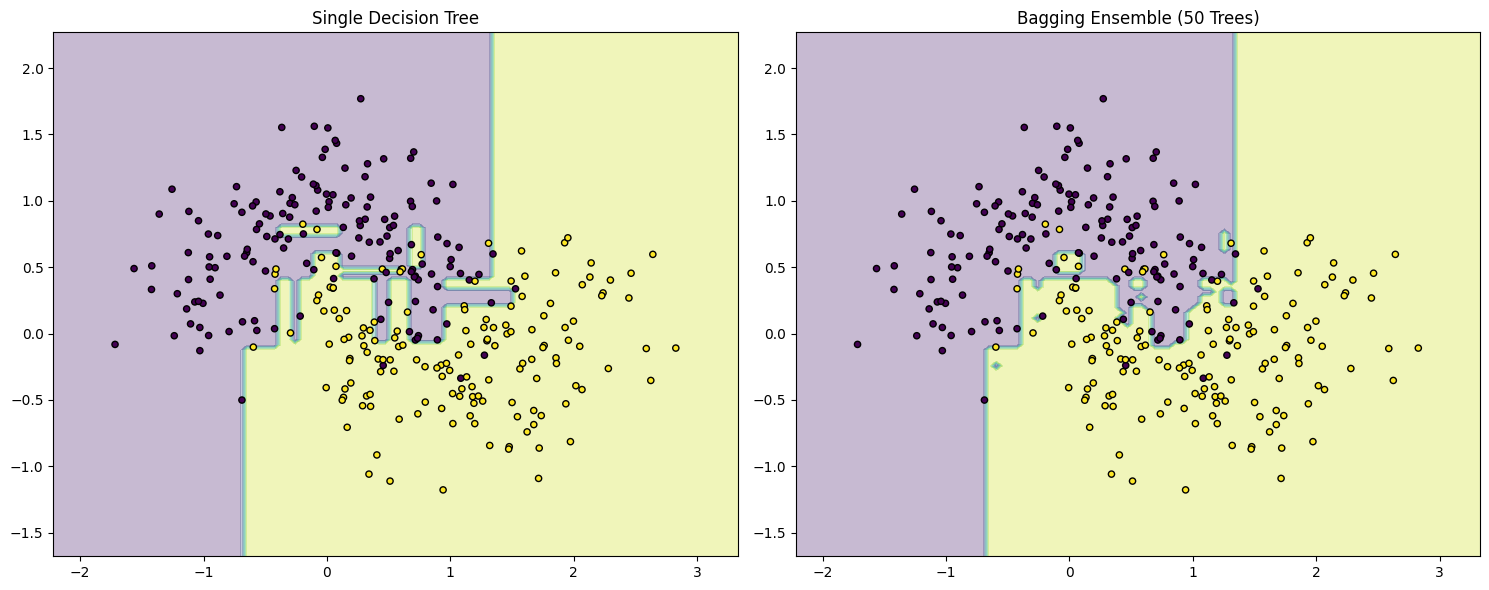

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage.supervised_learning import _BaseBagging, DecisionTree
from sklearn.datasets import make_moons

# 1. Generate a noisy "Moons" dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# 2. Setup Models
# A single deep tree (prone to high variance)
single_tree = DecisionTree(max_depth=10)

# An ensemble of 50 trees using our new engine
bagging_tree = _BaseBagging(
    base_estimator=DecisionTree(max_depth=10), 
    n_estimators=50, 
    random_state=42, 
    mode='hard_vote'
)

models = [("Single Decision Tree", single_tree), ("Bagging Ensemble (50 Trees)", bagging_tree)]

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, model) in enumerate(models):
    model.fit(X, y)
    
    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Predict
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contours
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
    axes[i].set_title(name)

plt.tight_layout()
plt.show()